Instructions to Run the Notebook

1. Open this notebook in Kaggle.
2. Add the dataset using the following link: https://www.kaggle.com/datasets/raddar/chest-xrays-indiana-university
3. Set the accelerator to GPU (T4 recommended).
4. Ensure GPU is enabled before running the notebook.
5. Run all cells sequentially.

In [17]:
# Import Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms

import pandas as pd
import numpy as np
from PIL import Image
import os
import re
from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
from nltk.translate.bleu_score import corpus_bleu
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# GPU Check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# File 
Data_Path = "/kaggle/input/datasets/raddar/chest-xrays-indiana-university/"
Image_Path = os.path.join(Data_Path, "images", "images_normalized")
Reports_Data = os.path.join(Data_Path, "indiana_reports.csv")
Projections_Data = os.path.join(Data_Path, "indiana_projections.csv")

In [4]:
# Data Loading
Reports_df = pd.read_csv(Reports_Data)
Projections_df = pd.read_csv(Projections_Data)
Projections_df = Projections_df[Projections_df['projection'] == 'Frontal']

Loading the data and filtering out the frontal images


### Data Preprocessing

In [5]:
# Merging the projections and Report
df = pd.merge(Reports_df, Projections_df, on='uid')

# Handling Missing Data
df['report'] = df['findings'].fillna('') + ' ' + df['impression'].fillna('')
df = df[['uid', 'MeSH', 'filename', 'report']].dropna(subset=['MeSH']).drop_duplicates(subset=['filename'])

# Subsampling to 2500 images for baseline Execution
df = df.sample(n=2500, random_state=42)

# Label Extraction and Encoding
Anatomy_Labels = {
    'lung', 'spine', 'aorta', 'thoracic vertebrae', 'heart', 'ribs', 'pleura', 
    'diaphragm', 'bones', 'bone', 'abdomen', 'shoulder', 'sternum', 'clavicle', 
    'mediastinum', 'trachea', 'normal', 'medical device', 'surgical instruments', 
    'implant', 'catheters', 'device removal', 'blood vessels', 'markings', 
    'soft tissue', 'lymph nodes', 'bronchi', 'pulmonary artery'
}

def Disease_Extraction(text):
    if pd.isna(text) or text.lower() == 'normal': return []
    findings = text.lower().split(';')
    clean_list = {item.split('/')[0].strip() for item in findings if item.split('/')[0].strip()}
    return [item for item in clean_list if item not in Anatomy_Labels]

df['raw_pathologies'] = df['MeSH'].apply(Disease_Extraction)

Target_Diseases = ['opacity', 'cardiomegaly', 'pulmonary atelectasis', 'pleural effusion']
def Final_Label_Assignment(Disease_List):
    filtered = [l for l in Disease_List if l in Target_Diseases]
    return filtered if filtered else ['normal']

df['labels'] = df['raw_pathologies'].apply(Final_Label_Assignment)

mlb = MultiLabelBinarizer()
df['encoded_labels'] = list(mlb.fit_transform(df['labels']))
num_classes = len(mlb.classes_)

In [6]:
# train test split
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

In [7]:
# Vocabulary and Dataset
class Vocabulary:
    def __init__(self, freq_threshold):
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {v: k for k, v in self.itos.items()}
        self.freq_threshold = freq_threshold
        
    def __len__(self): return len(self.itos)
    
    def Tokenizing(self, text):
        text = text.lower()
        text = re.sub(r'[^\w\s.]', '', text)
        return re.sub(r'\s+', ' ', text).strip().split(' ')
        
    def Vocabulary_Building(self, sentence_list):
        frequencies = Counter()
        for s in sentence_list:
            for w in self.Tokenizing(s): frequencies[w] += 1
        idx = 4
        for w, count in frequencies.items():
            if count >= self.freq_threshold:
                self.itos[idx] = w; self.stoi[w] = idx; idx += 1
                
    def Numerizing(self, text): 
        return [self.stoi.get(w, self.stoi["<UNK>"]) for w in self.Tokenizing(text)]
vocab = Vocabulary(freq_threshold=5)
vocab.Vocabulary_Building(train_df['report'].tolist())

class XRayDataset(Dataset):
    def __init__(self, df, transform, vocab=None, is_generator=False): 
        self.df = df; self.transform = transform; self.vocab = vocab; self.is_generator = is_generator
        
    def __len__(self): return len(self.df)
    
    def __getitem__(self, index):
        row = self.df.iloc[index]
        labels = torch.FloatTensor(row['encoded_labels'])
        if not self.is_generator:
            image = Image.open(os.path.join(Image_Path, row['filename'])).convert("RGB")
            return self.transform(image), labels
        else:
            num_rep = [self.vocab.stoi["<SOS>"]] + self.vocab.Numerizing(row['report']) + [self.vocab.stoi["<EOS>"]]
            return labels, torch.tensor(num_rep)

In [8]:
# Hyperparameters
BATCH_SIZE = 64
NUM_EPOCHS = 5
LEARNING_RATE_CLASSIFIER = 3e-4 
LEARNING_RATE_GENERATOR = 3e-4 
EMBED_SIZE = 128     
HIDDEN_SIZE = 256   

In [9]:
# Data Loader
train_transform = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_loader_cls = DataLoader(XRayDataset(train_df, train_transform), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader_cls = DataLoader(XRayDataset(val_df, val_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class GenCollate:
    def __init__(self, pad_idx): self.pad_idx = pad_idx
    def __call__(self, batch):
        labels = torch.stack([item[0] for item in batch], 0)
        reports = nn.utils.rnn.pad_sequence([item[1] for item in batch], batch_first=True, padding_value=self.pad_idx)
        return labels, reports

train_loader_gen = DataLoader(XRayDataset(train_df, None, vocab, True), batch_size=BATCH_SIZE, shuffle=True, collate_fn=GenCollate(vocab.stoi["<PAD>"]), num_workers=2)

In [10]:
# Model Definition
class AcademicBaselineClassifier(nn.Module):
    def __init__(self, n_classes):
        super(AcademicBaselineClassifier, self).__init__()
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        # 1. Freeze all layers initially
        for param in self.resnet.parameters(): 
            param.requires_grad = False
            
        # 2. Unfreeze ONLY the final convolutional block (layer4) for fine-tuning
        for param in self.resnet.layer4.parameters():
            param.requires_grad = True
            
        # 3. Replace and unfreeze the final classification head
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, n_classes)
        
    def forward(self, x): 
        return self.resnet(x)

class AcademicBaselineGenerator(nn.Module):
    def __init__(self, n_classes, embed_size, hidden_size, vocab_size, num_layers=1):
        super(AcademicBaselineGenerator, self).__init__()
        self.label_encoder = nn.Linear(n_classes, hidden_size)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        self.fc_out = nn.Linear(hidden_size, vocab_size)
        
    def forward(self, labels, reports):
        hidden = self.label_encoder(labels).unsqueeze(0) 
        cell = torch.zeros(hidden.size()).to(labels.device)
        embeds = self.embedding(reports[:, :-1]) 
        out, _ = self.lstm(embeds, (hidden, cell))
        return self.fc_out(out)

### Model Training

In [11]:
# Classifier Training 
classifier_baseline = AcademicBaselineClassifier(num_classes).to(device)
criterion_cls = nn.BCEWithLogitsLoss() 
optimizer_cls = torch.optim.Adam(filter(lambda p: p.requires_grad, classifier_baseline.parameters()), lr=LEARNING_RATE_CLASSIFIER)

print(f"\nClassifier Training")
for epoch in range(NUM_EPOCHS):
    classifier_baseline.train()
    total_loss = 0
    for images, labels in train_loader_cls:
        images, labels = images.to(device), labels.to(device)
        optimizer_cls.zero_grad()
        loss = criterion_cls(classifier_baseline(images), labels)
        loss.backward()
        optimizer_cls.step()
        total_loss += loss.item()
    print(f"Classifier Epoch {epoch+1}/{NUM_EPOCHS} - Standard BCE Loss: {total_loss/len(train_loader_cls):.4f}")



Classifier Training
Classifier Epoch 1/5 - Standard BCE Loss: 0.3981
Classifier Epoch 2/5 - Standard BCE Loss: 0.1538
Classifier Epoch 3/5 - Standard BCE Loss: 0.0549
Classifier Epoch 4/5 - Standard BCE Loss: 0.0231
Classifier Epoch 5/5 - Standard BCE Loss: 0.0134


In [12]:
# Generator training
generator_baseline = AcademicBaselineGenerator(num_classes, EMBED_SIZE, HIDDEN_SIZE, len(vocab)).to(device)
criterion_gen = nn.CrossEntropyLoss(ignore_index=vocab.stoi["<PAD>"])
optimizer_gen = torch.optim.Adam(generator_baseline.parameters(), lr=LEARNING_RATE_GENERATOR)

print("\nGenerator Training")
for epoch in range(NUM_EPOCHS): 
    generator_baseline.train()
    total_loss = 0
    for labels, reports in train_loader_gen:
        labels, reports = labels.to(device), reports.to(device)
        optimizer_gen.zero_grad()
        outputs = generator_baseline(labels, reports)
        loss = criterion_gen(outputs.reshape(-1, outputs.shape[-1]), reports[:, 1:].reshape(-1))
        loss.backward()
        optimizer_gen.step()
        total_loss += loss.item()
    print(f"Generator Epoch {epoch+1}/{NUM_EPOCHS} - Loss: {total_loss/len(train_loader_gen):.4f}")



Generator Training
Generator Epoch 1/5 - Loss: 6.4762
Generator Epoch 2/5 - Loss: 5.2623
Generator Epoch 3/5 - Loss: 4.8055
Generator Epoch 4/5 - Loss: 4.5125
Generator Epoch 5/5 - Loss: 4.2222


### Evaluation

In [13]:
# Classifier Evaluation
classifier_baseline.eval()
all_logits, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader_cls:
        all_logits.append(classifier_baseline(images.to(device)).cpu())
        all_labels.append(labels.cpu())

all_logits = torch.cat(all_logits)
all_labels = torch.cat(all_labels).numpy()

best_f1_thresh, best_threshold = 0.0, 0.5
for thresh in np.arange(0.1, 0.9, 0.05):
    preds = (torch.sigmoid(all_logits) > thresh).numpy()
    f1 = f1_score(all_labels, preds, average='micro', zero_division=0)
    if f1 > best_f1_thresh:
        best_f1_thresh = f1; best_threshold = thresh

print(f"Optimal Classifier Threshold: {best_threshold:.2f}")
print(f"Best Validation F1 Score (Micro): {best_f1_thresh:.4f}")
final_preds = (torch.sigmoid(all_logits) > best_threshold).numpy()
print(classification_report(all_labels, final_preds, target_names=mlb.classes_, zero_division=0))


Optimal Classifier Threshold: 0.40
Best Validation F1 Score (Micro): 0.7385
                       precision    recall  f1-score   support

         cardiomegaly       0.56      0.24      0.33        38
               normal       0.84      0.93      0.88       282
              opacity       0.46      0.15      0.23        39
     pleural effusion       1.00      0.07      0.12        15
pulmonary atelectasis       0.33      0.12      0.18        33

            micro avg       0.79      0.69      0.74       407
            macro avg       0.64      0.30      0.35       407
         weighted avg       0.74      0.69      0.68       407
          samples avg       0.74      0.73      0.73       407



In [14]:
# Generator Evaluation
generator_baseline.eval()

def Greedy_Search_Generation(model, labels_tensor, vocab, max_len=50):
    start_token = vocab.stoi["<SOS>"]
    eos_token = vocab.stoi["<EOS>"]
    
    hidden = model.label_encoder(labels_tensor).unsqueeze(0)
    cell = torch.zeros(hidden.size()).to(device)
    current_token = torch.tensor([[start_token]]).to(device)
    generated_words = []
    
    for _ in range(max_len):
        embeds = model.embedding(current_token)
        out, (hidden, cell) = model.lstm(embeds, (hidden, cell))
        preds = model.fc_out(out)
        next_token = preds.argmax(dim=-1)
        token_id = next_token.item()
        
        if token_id == eos_token: break
        generated_words.append(vocab.itos.get(token_id, "<UNK>"))
        current_token = next_token 
        
    return " ".join(generated_words)

test_subset = test_df.head(100) 
results = []
with torch.no_grad():
    for _, row in test_subset.iterrows():
        true_labels_tensor = torch.FloatTensor(row['encoded_labels']).unsqueeze(0).to(device)
        generated_report = Greedy_Search_Generation(generator_baseline, true_labels_tensor, vocab)
        results.append({
            "true_report": row['report'],
            "generated_report": generated_report
        })

results_df = pd.DataFrame(results)
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
true_reportsTokenizingd = [[r.split()] for r in results_df['true_report']]
gensTokenizingd = [r.split() for r in results_df['generated_report']]

print(f"Baseline BLEU-4 Score (Greedy):  {corpus_bleu(true_reportsTokenizingd, gensTokenizingd):.4f}")
print(f"Baseline ROUGE-L Score: {np.mean([scorer.score(r['true_report'], r['generated_report'])['rougeL'].fmeasure for _, r in results_df.iterrows()]):.4f}")

Baseline BLEU-4 Score (Greedy):  0.0000
Baseline ROUGE-L Score: 0.2438


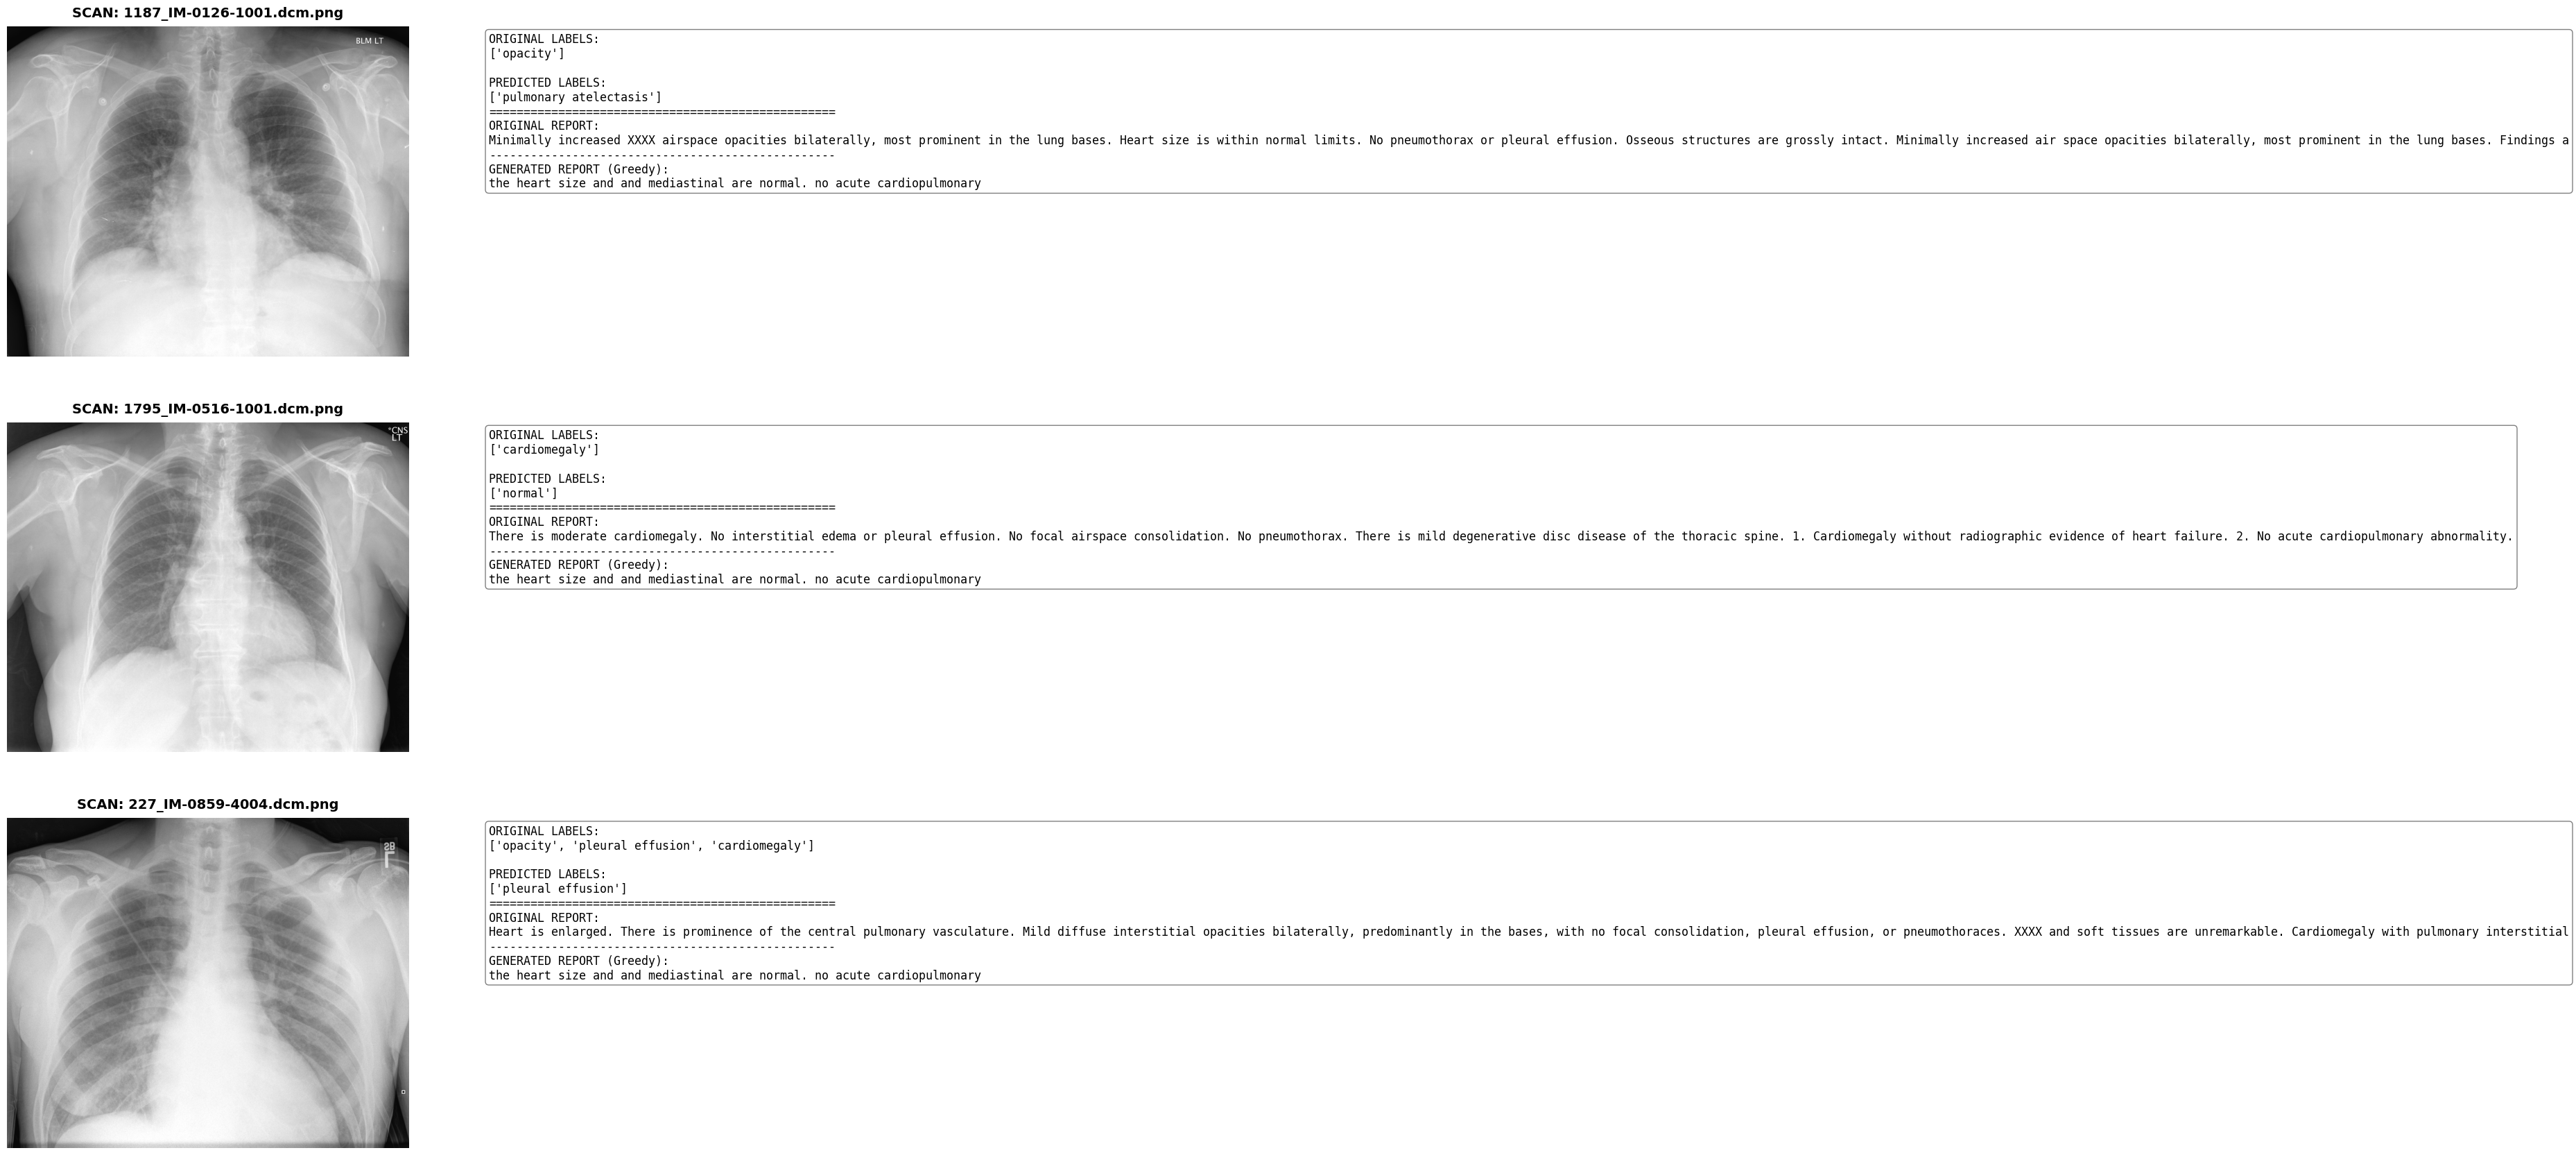

In [22]:
# Result Visualization
def Sample_Visualisation(model_cls, model_gen, test_df, mlb, vocab, num_samples=3):
    Pathological_df = test_df[
        test_df['labels'].apply(lambda x: 'normal' not in x)
    ].head(num_samples)
 
    if Pathological_df.empty:
        print("Non-normal images were not found in this test set.")
        return
 
    model_cls.eval()
    model_gen.eval()
 
    fig, axes = plt.subplots(
        len(Pathological_df), 2,
        figsize=(18, 7 * len(Pathological_df))
    )
 
    if len(Pathological_df) == 1:
        axes = axes.reshape(1, 2)
 
    with torch.no_grad():
        for i, (idx, row) in enumerate(Pathological_df.iterrows()):
 
            img_path   = os.path.join(Image_Path, row['filename'])
            raw_image  = Image.open(img_path).convert("RGB")
            input_tensor = val_transform(raw_image).unsqueeze(0).to(device)
 
            logits      = model_cls(input_tensor)
            preds       = (torch.sigmoid(logits) > best_threshold).cpu().numpy()
            pred_labels = mlb.inverse_transform(preds)[0]
 
            pred_labels_tensor = torch.FloatTensor(preds).to(device)
            gen_report         = Greedy_Search_Generation(model_gen, pred_labels_tensor, vocab)
 
            axes[i, 0].imshow(raw_image, cmap='gray')
            axes[i, 0].set_title(
                f"SCAN: {row['filename']}",
                fontsize=14, fontweight='bold', pad=10
            )
            axes[i, 0].axis('off')
 
            Text_Display = (
                f"ORIGINAL LABELS:\n{row['labels']}\n\n"
                f"PREDICTED LABELS:\n{list(pred_labels)}\n"
                f"{'='*50}\n"
                f"ORIGINAL REPORT:\n{row['report'][:300]}\n"
                f"{'-'*50}\n"
                f"GENERATED REPORT (Greedy):\n{gen_report}"
            )
 
            axes[i, 1].text(
                0.01, 0.98, Text_Display,
                fontsize=12,
                verticalalignment='top',
                horizontalalignment='left',
                family='monospace',
                transform=axes[i, 1].transAxes,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.5)
            )
            axes[i, 1].axis('off')
 
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.1)
    plt.show()
 
Sample_Visualisation(
    classifier_baseline, generator_baseline,
    test_df, mlb, vocab,
    num_samples=3
)

In [20]:
# Save Models
torch.save(classifier_baseline.state_dict(), "academic_baseline_classifier_earlystop.pth")
torch.save(generator_baseline.state_dict(), "academic_baseline_generator_earlystop.pth")